# Item Recognition Initial Evaluation

Evaluates the comparison pipeline's item-level change detection against the golden
captures produced and marked manually by capture app variant, using the item-marking ground-truth
format (each ground-truth entry references a specific marked item by id, rather than
matching by name).

**Data source:** `experiments/device_data/`, pulled from the device via `adb` — see
`experiments/README.md` for what's in there and how to refresh it.

**Scope:** only the most recent test run (`test_results/pipeline_test_latest.json`) is
used. Golden captures whose ground truth predates item-marking (matched by item name
instead of a marked item id) are detected and skipped automatically — this notebook is
written to keep working as more references and golden captures are added over time,
without needing changes.

**Metric:** exact change-type match. For every marked item the pipeline reported on, its
predicted `change` (`UNCHANGED`, `REMOVED`, `REPLACED`, ...) is compared against the
ground-truth `change_type` (or the implicit `UNCHANGED` if the item isn't in ground
truth at all). Precision/recall/F1 are computed per class plus a weighted-average
headline number, with a confusion matrix to keep the small sample size visible rather
than hidden behind one number.

## 1. Setup

In [1]:
import json
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, f1_score

pd.set_option("display.max_colwidth", None)

nb_file = globals().get("__vsc_ipynb_file__")
NOTEBOOK_DIR = Path(nb_file).parent if nb_file else Path.cwd()
DEVICE_DATA_DIR = NOTEBOOK_DIR.parent / "device_data"
STORAGES_DIR = DEVICE_DATA_DIR / "storages"
GOLDENS_DIR = DEVICE_DATA_DIR / "golden" / "comparisons"
TEST_RESULTS_PATH = DEVICE_DATA_DIR / "test_results" / "pipeline_test_latest.json"
ALIGNED_DIR = DEVICE_DATA_DIR / "test_results" / "aligned"

CHANGE_TYPES = [
    "UNCHANGED", "REMOVED", "REPLACED", "ADDED",
    "PARTIALLY_CONSUMED", "FULLY_CONSUMED",
    "PARTIALLY_FILLED", "FULLY_FILLED", "UNKNOWN",
]

CHANGE_COLORS = {
    "UNCHANGED": "#888888",
    "REMOVED": "#C44E52",
    "ADDED": "#55A868",
    "REPLACED": "#DD8452",
    "PARTIALLY_CONSUMED": "#DD8452",
    "FULLY_CONSUMED": "#DD8452",
    "PARTIALLY_FILLED": "#DD8452",
    "FULLY_FILLED": "#DD8452",
    "UNKNOWN": "#DD8452",
}

print(f"device data: {DEVICE_DATA_DIR}")

device data: C:\Users\jugur\AndroidStudioProjects\HomeShelf\experiments\device_data


## 2. Load Device Data

Loads every storage (reference photo, shelf grid, marked items) and every golden
capture (the "after" photo plus its own ground-truth metadata) found under
`device_data/`, plus the latest pipeline test report.

In [2]:
def load_storages(storages_dir):
    storages = {}
    for storage_dir in sorted(storages_dir.iterdir()):
        if not storage_dir.is_dir():
            continue
        meta = json.loads((storage_dir / "meta.json").read_text())
        latest_dir = storage_dir / "latest"
        data = json.loads((latest_dir / "data.json").read_text())
        storages[meta["id"]] = {
            "meta": meta,
            "guide_lines": data.get("guideLines", []),
            "marked_items": data.get("markedItems", []),
            "photo_path": latest_dir / "photo.jpg",
        }
    return storages


def load_goldens(goldens_dir):
    goldens = {}
    for golden_dir in sorted(goldens_dir.iterdir()):
        if not golden_dir.is_dir():
            continue
        meta = json.loads((golden_dir / "meta.json").read_text())
        goldens[meta["name"]] = {
            "meta": meta,
            "photo_path": golden_dir / "photo.jpg",
        }
    return goldens


storages = load_storages(STORAGES_DIR)
goldens = load_goldens(GOLDENS_DIR)
test_report = json.loads(TEST_RESULTS_PATH.read_text())

print(f"storages: {[s['meta']['name'] for s in storages.values()]}")
print(f"golden captures: {len(goldens)}")
print(f"test run: {test_report['timestamp']}")
print(f"goldens in report: {[g['golden_name'] for g in test_report['goldens']]}")

storages: ['vitrina']
golden captures: 2
test run: 2026-08-15T18:53:48.234554Z
goldens in report: ['vitrina_20260815_173758', 'vitrina_20260813_221547', 'Workshop _20260624_204821', 'pantry_20260627_143831', 'Hotel minibar_20260714_134947']


## 3. Filter to Item-Marked Goldens

Legacy Captures: Older tests matched items by name instead of ID, so their item_id shows as null.

Inclusion Rule: A golden capture is kept only if its storage unit has marked items, and every ground-truth entry satisfies one of two conditions:

It references a marked item by its item_id.

It is an ADDED item (which never has an item_id because it did not exist in the reference photo).

**Note:** `device_data/` itself has since been pruned to only the storages/goldens that
have marked items (`vitrina`, at the moment) — the other legacy storages and their
golden captures were deleted rather than kept around unused. The filter above is left
in place regardless, since it costs nothing and keeps this notebook correct the moment
a new pre-item-marking capture shows up again.

In [3]:
def is_item_marked(golden_report, goldens, storages):
    golden_meta = goldens.get(golden_report["golden_name"], {}).get("meta")
    if golden_meta is None:
        return False
    storage = storages.get(golden_meta.get("storage_id"))
    if not storage or not storage["marked_items"]:
        return False
    return all(
        gt.get("item_id") or gt.get("change_type") == "ADDED"
        for gt in golden_report["ground_truth"]
    )


item_marked_goldens = [g for g in test_report["goldens"] if is_item_marked(g, goldens, storages)]
skipped_names = [g["golden_name"] for g in test_report["goldens"] if g not in item_marked_goldens]

print(f"item-marked goldens ({len(item_marked_goldens)}): {[g['golden_name'] for g in item_marked_goldens]}")
print(f"skipped, pre item-marking ground truth ({len(skipped_names)}): {skipped_names}")

item-marked goldens (2): ['vitrina_20260815_173758', 'vitrina_20260813_221547']
skipped, pre item-marking ground truth (3): ['Workshop _20260624_204821', 'pantry_20260627_143831', 'Hotel minibar_20260714_134947']


## 4. Build the Per-Item Scoring Table

**1. Items Already Known (Items on the shelf before)**

How they are matched: Each item has an ID. The system directly compares the real-world result (ground truth) with what the AI predicted.
Default rule: If an item isn't mentioned in the ground truth, it is assumed to be UNCHANGED.
Handling crashes/misses: If the pipeline fails or crashes on an item, it counts as a prediction of UNCHANGED. This ensures system failures are scored as missed detections rather than ignored.

**2. Newly Added Items (Items not there before)**

How they are matched: New items do not have IDs. Instead, the system checks whether the drawn box around the real item overlaps with the box predicted by the AI. Pairs with the highest overlap are matched first.
Approximate match: The real-life box and the AI's box are drawn on slightly different versions of the photo (raw vs. aligned), so a rough overlap is enough.

Scoring outcomes:

- Both agree an item was added: Correct detection (True Positive).
- Item was added in real life, but AI saw nothing: Missed item (False Negative).
- AI detected a new item, but nothing was added: False alarm (False Positive).
- Old test data without boxes: Left unscored because they cannot be matched visually.

In [4]:
def iou(box_a, box_b):
    left = max(box_a["x"], box_b["x"])
    top = max(box_a["y"], box_b["y"])
    right = min(box_a["x"] + box_a["width"], box_b["x"] + box_b["width"])
    bottom = min(box_a["y"] + box_a["height"], box_b["y"] + box_b["height"])
    intersection = max(right - left, 0) * max(bottom - top, 0)
    union = box_a["width"] * box_a["height"] + box_b["width"] * box_b["height"] - intersection
    return intersection / union if union > 0 else 0.0


def match_added_items(added_predicted, added_ground_truth):
    predicted_with_box = [p for p in added_predicted if p.get("box")]
    gt_with_box = [gt for gt in added_ground_truth if gt.get("box")]

    candidates = sorted(
        (
            (iou(gt["box"], p["box"]), gt_idx, p_idx)
            for gt_idx, gt in enumerate(gt_with_box)
            for p_idx, p in enumerate(predicted_with_box)
        ),
        key=lambda c: -c[0],
    )

    matched_gt, matched_pred, matches = set(), set(), []
    for score, gt_idx, p_idx in candidates:
        if score <= 0 or gt_idx in matched_gt or p_idx in matched_pred:
            continue
        matched_gt.add(gt_idx)
        matched_pred.add(p_idx)
        matches.append((gt_with_box[gt_idx], predicted_with_box[p_idx], score))

    unmatched_gt = [gt for i, gt in enumerate(gt_with_box) if i not in matched_gt]
    unmatched_pred = [p for i, p in enumerate(predicted_with_box) if i not in matched_pred]
    no_box_predicted = [p for p in added_predicted if not p.get("box")]
    no_box_gt = [gt for gt in added_ground_truth if not gt.get("box")]
    return matches, unmatched_gt, unmatched_pred, no_box_predicted, no_box_gt


def build_item_rows(golden_report, storages, goldens):
    golden_meta = goldens[golden_report["golden_name"]]["meta"]
    storage = storages[golden_meta["storage_id"]]
    item_names = {item["id"]: item["name"] for item in storage["marked_items"]}
    known_item_ids = set(item_names)

    ai_items_by_id = {
        ai_item["id"]: {**ai_item, "cell_id": cell["cell_id"]}
        for cell in golden_report["cells"]
        for ai_item in cell["ai_items"]
    }
    known_ai_items = {k: v for k, v in ai_items_by_id.items() if k in known_item_ids}
    ground_truth_by_id = {
        gt["item_id"]: gt for gt in golden_report["ground_truth"] if gt.get("item_id")
    }

    rows = []
    for item_id, ai_item in known_ai_items.items():
        gt = ground_truth_by_id.get(item_id)
        rows.append({
            "golden_name": golden_report["golden_name"],
            "cell_id": ai_item["cell_id"],
            "item_id": item_id,
            "item_name": item_names.get(item_id, ai_item.get("name") or "?"),
            "true_change": gt["change_type"] if gt else "UNCHANGED",
            "predicted_change": ai_item["change"],
            "description": ai_item["description"],
            "reported": True,
            "iou": None,
        })

    for item_id, gt in ground_truth_by_id.items():
        if item_id in known_ai_items:
            continue
        rows.append({
            "golden_name": golden_report["golden_name"],
            "cell_id": gt.get("cell_name"),
            "item_id": item_id,
            "item_name": item_names.get(item_id, gt["name"]),
            "true_change": gt["change_type"],
            "predicted_change": "UNCHANGED",
            "description": "(not reported by pipeline)",
            "reported": False,
            "iou": None,
        })

    added_predicted = [
        {**ai_item, "cell_id": cell["cell_id"]}
        for cell in golden_report["cells"]
        for ai_item in cell["ai_items"]
        if ai_item["id"] not in known_item_ids
    ]
    added_ground_truth = [gt for gt in golden_report["ground_truth"] if not gt.get("item_id")]
    matches, unmatched_gt, unmatched_pred, no_box_predicted, no_box_gt = match_added_items(
        added_predicted, added_ground_truth
    )

    for gt, p, score in matches:
        rows.append({
            "golden_name": golden_report["golden_name"],
            "cell_id": gt.get("cell_name") or p["cell_id"],
            "item_id": f"added:{p['id']}",
            "item_name": gt["name"],
            "true_change": "ADDED",
            "predicted_change": "ADDED",
            "description": p["description"],
            "reported": True,
            "iou": round(score, 2),
        })
    for gt in unmatched_gt:
        rows.append({
            "golden_name": golden_report["golden_name"],
            "cell_id": gt.get("cell_name"),
            "item_id": f"added-gt:{gt['name']}",
            "item_name": gt["name"],
            "true_change": "ADDED",
            "predicted_change": "UNCHANGED",
            "description": "(no overlapping prediction)",
            "reported": False,
            "iou": None,
        })
    for p in unmatched_pred:
        rows.append({
            "golden_name": golden_report["golden_name"],
            "cell_id": p["cell_id"],
            "item_id": f"added-pred:{p['id']}",
            "item_name": p.get("name") or "?",
            "true_change": "UNCHANGED",
            "predicted_change": "ADDED",
            "description": p["description"],
            "reported": True,
            "iou": None,
        })

    added_with_box_for_display = {
        "gt": [gt for gt, _, _ in matches] + unmatched_gt,
        "predicted": [p for _, p, _ in matches] + unmatched_pred,
    }
    return rows, no_box_predicted, no_box_gt, added_with_box_for_display


scored_rows = []
added_by_golden = {}
for golden_report in item_marked_goldens:
    rows, no_box_predicted, no_box_gt, added_with_box = build_item_rows(golden_report, storages, goldens)
    scored_rows.extend(rows)
    added_by_golden[golden_report["golden_name"]] = (no_box_predicted, no_box_gt, added_with_box)

items_df = pd.DataFrame(scored_rows)
total_unscored = sum(len(p) + len(g) for p, g, _ in added_by_golden.values())
print(f"items scored: {len(items_df)} (see the per-golden tables in section 7)")
print(f"added items with no box at all, still unscored: {total_unscored} (see section 7)")

items scored: 17 (see the per-golden tables in section 7)
added items with no box at all, still unscored: 0 (see section 7)


## 5. Metrics

Exact change-type match, per class and as F1. The
confusion matrix and per-class report always use the full 9-state `ItemChange` set
(`CHANGE_TYPES`), not just whatever happens to appear in this run's data — so a class
with zero occurrences still shows as an all-zero row/column instead of disappearing,
and the shape stays identical from one run to the next.

In [5]:
labels_present = CHANGE_TYPES

f1_weighted = f1_score(
    items_df["true_change"], items_df["predicted_change"],
    labels=labels_present, average="weighted", zero_division=0,
)

print(f"Items scored: {len(items_df)}")
print(f"Weighted F1 (exact change-type match): {f1_weighted:.3f}\n")
print(classification_report(
    items_df["true_change"], items_df["predicted_change"],
    labels=labels_present, zero_division=0,
))

Items scored: 17
Weighted F1 (exact change-type match): 0.853

                    precision    recall  f1-score   support

         UNCHANGED       0.86      1.00      0.92        12
           REMOVED       1.00      0.75      0.86         4
          REPLACED       0.00      0.00      0.00         0
             ADDED       0.00      0.00      0.00         1
PARTIALLY_CONSUMED       0.00      0.00      0.00         0
    FULLY_CONSUMED       0.00      0.00      0.00         0
  PARTIALLY_FILLED       0.00      0.00      0.00         0
      FULLY_FILLED       0.00      0.00      0.00         0
           UNKNOWN       0.00      0.00      0.00         0

          accuracy                           0.88        17
         macro avg       0.21      0.19      0.20        17
      weighted avg       0.84      0.88      0.85        17



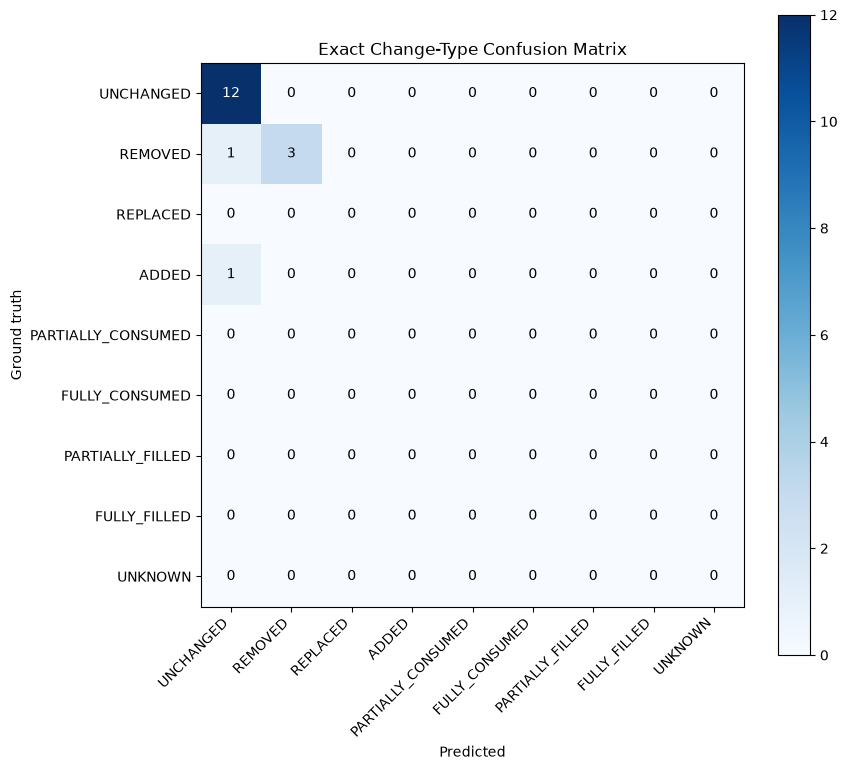

In [6]:
cm = confusion_matrix(items_df["true_change"], items_df["predicted_change"], labels=labels_present)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(labels_present)))
ax.set_yticks(range(len(labels_present)))
ax.set_xticklabels(labels_present, rotation=45, ha="right")
ax.set_yticklabels(labels_present)
ax.set_xlabel("Predicted")
ax.set_ylabel("Ground truth")
ax.set_title("Exact Change-Type Confusion Matrix")
for i in range(len(labels_present)):
    for j in range(len(labels_present)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im)
plt.tight_layout()
plt.show()

## 6. Golden Capture Metadata

In [7]:
meta_rows = []
for golden_report in item_marked_goldens:
    golden_meta = goldens[golden_report["golden_name"]]["meta"]
    storage_meta = storages[golden_meta["storage_id"]]["meta"]
    meta_rows.append({
        "golden_name": golden_report["golden_name"],
        "storage": storage_meta["name"],
        "captured_at": golden_report["captured_at"],
        "alignment_success": golden_report["alignment_success"],
        "error": golden_report.get("error"),
        "device_model": golden_meta.get("device_model"),
        "android_api": golden_meta.get("android_api"),
        "image_size": f'{golden_meta.get("image_width")}x{golden_meta.get("image_height")}',
    })

pd.DataFrame(meta_rows)

,golden_name,storage,captured_at,alignment_success,error,device_model,android_api,image_size
0,vitrina_20260815_173758,vitrina,2026-08-15T15:39:25.407060Z,True,None,samsung SM-S921B,36,1080x1955
1,vitrina_20260813_221547,vitrina,2026-08-13T20:15:59.447577Z,True,None,samsung SM-S921B,36,1080x1955


## 7. Per-Golden Detail

For each golden capture, one row of three photos, its scoring table, and (when
present) any leftover unscored `ADDED` items:

- **Reference** — the reference photo with the shelf grid and every marked item
  outlined (thin boxes, name label), same as before.
- **Ground truth** — the golden capture, with every marked item's box colored by its
  true status: gray/translucent for `UNCHANGED`, red for `REMOVED`, green for `ADDED`,
  orange for any other change (`REPLACED`, `*_CONSUMED`, `*_FILLED`, `UNKNOWN`) —
  labeled with the exact type. Any ground-truth `ADDED` box (matched or not) is drawn
  here too, in green.
- **Pipeline result** — the same golden capture, but only items the pipeline predicted
  as changed are drawn, in the same color scheme, so it's a direct visual diff against
  the ground truth photo next to it. Any predicted `ADDED` box (matched or not) is
  drawn here in green — if you see two green boxes roughly overlapping in the same
  spot across the two panels, that's a matched pair; a green box in only one panel is
  a miss or a false positive.

**How Bounding Boxes and Images Align**

Coordinate System: The bounding boxes for marked items are stored as fractional coordinates of the original reference photo.

Aligned "After" Images: To ensure boxes match the new photo geometrically, ComparisonPipelineGoldenTest saves the homography-aligned "after" image (test_results/aligned/<goldenName>.jpg). The bounding boxes are valid in this aligned frame, so this image is used whenever it is available.

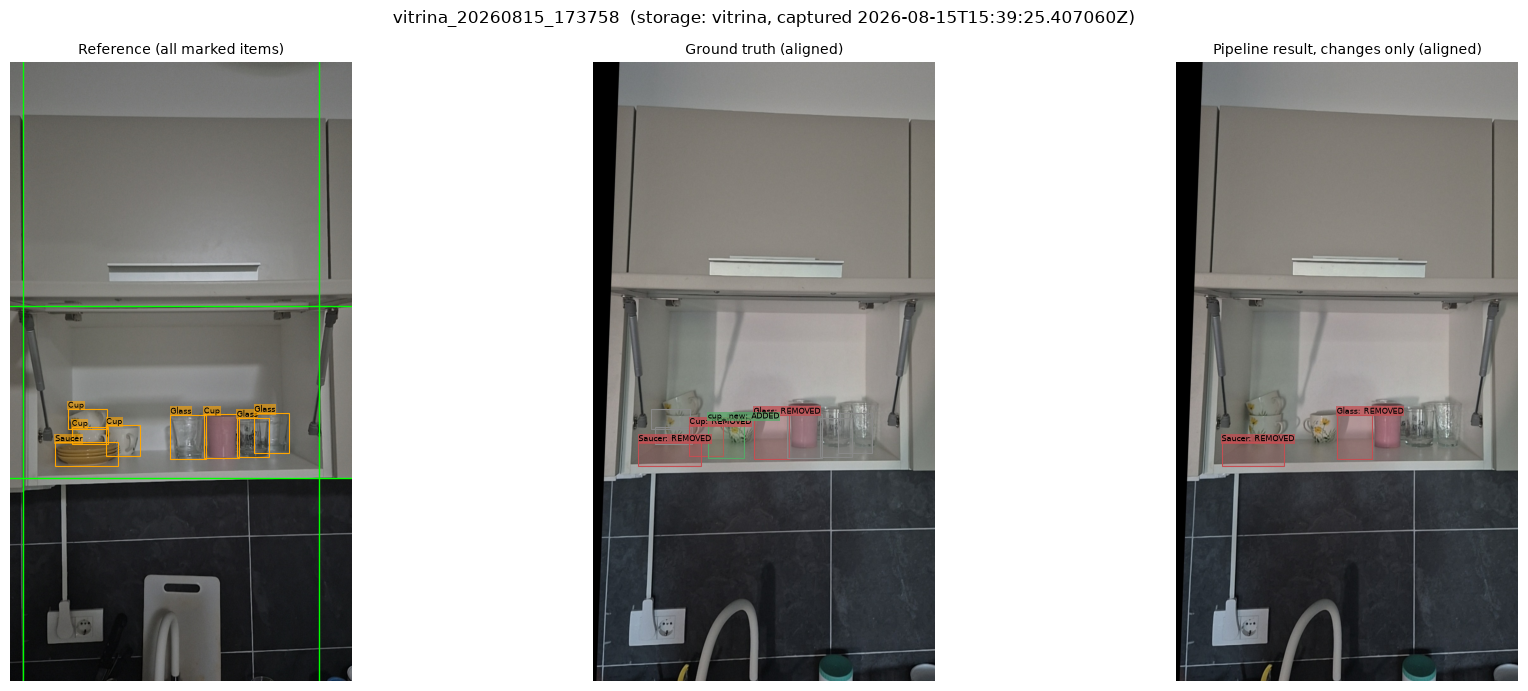

,cell_id,item_id,item_name,true_change,predicted_change,description,reported,iou
1,A1,16a83298-be42-472c-ac1f-7ca16675c3fd,Cup,UNCHANGED,UNCHANGED,Top floral cup remains stacked on the lower cup.,True,None
2,A1,ad33b608-f942-4aa8-8634-fe24ca6839df,Cup,UNCHANGED,UNCHANGED,"Lower floral cup remains in place, now resting directly on the shelf floor.",True,None
3,A1,4bda39db-b8b0-4c7f-8c7d-8f96c40da446,Cup,REMOVED,UNCHANGED,Floral cup to the right remains on the shelf.,True,None
5,A1,30ef06fe-b972-44bf-8dc1-8af7a27f480e,Cup,UNCHANGED,UNCHANGED,Pink cup remains in position on the shelf.,True,None
4,A1,1da9b1c5-7176-46ac-9db9-5f03e9961501,Glass,REMOVED,REMOVED,The clear glass that was to the left of the pink cup is gone.,True,None
6,A1,0b1ac9c5-59cf-43d4-893f-cb698641747b,Glass,UNCHANGED,UNCHANGED,Printed glass remains in place on the shelf.,True,None
7,A1,7d40eca1-1684-407a-af0f-d03f40488acc,Glass,UNCHANGED,UNCHANGED,Textured clear glass remains near the back right corner.,True,None
0,A1,de3e7403-7b6e-4b22-8919-2d5a544a6f61,Saucer,REMOVED,REMOVED,The yellow saucers beneath the stacked cups are no longer present on the shelf.,True,None
8,A1,added-gt:cup_ new,cup_ new,ADDED,UNCHANGED,(no overlapping prediction),False,None


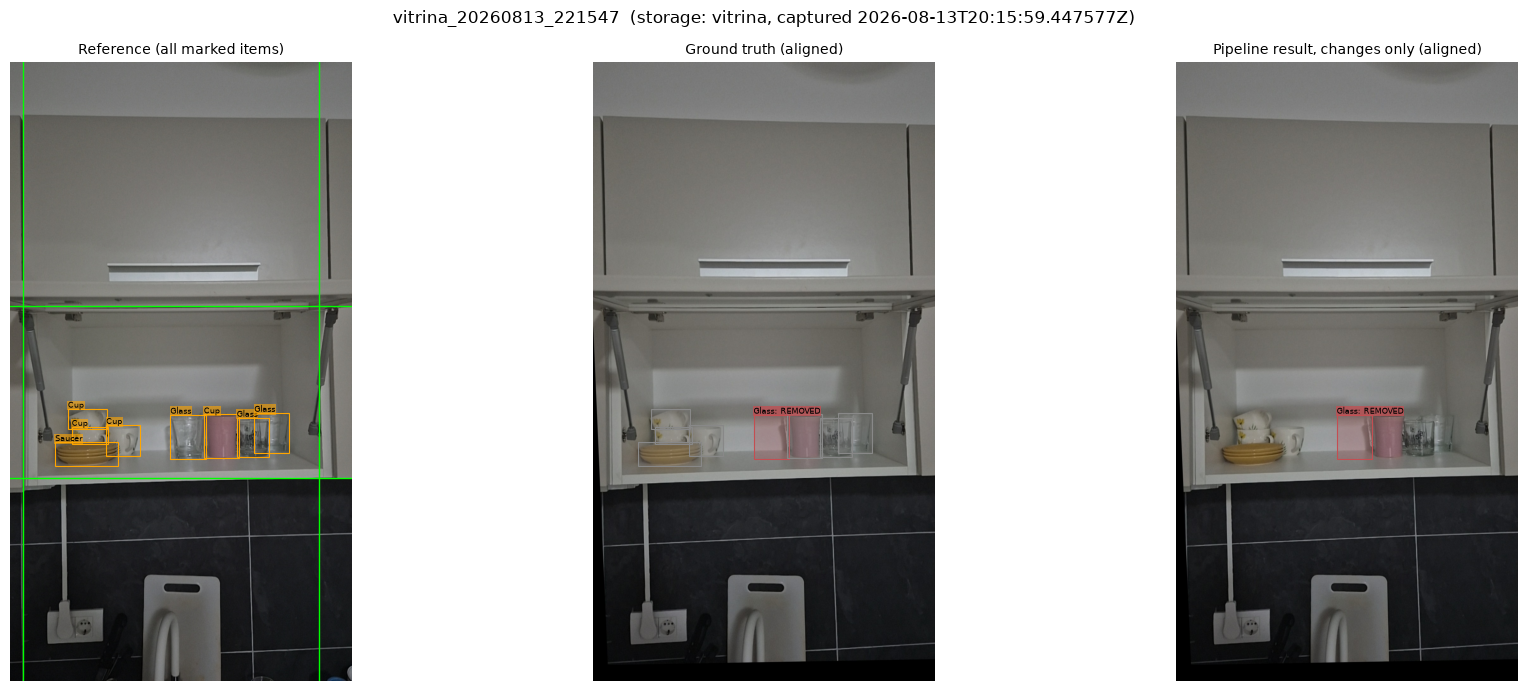

,cell_id,item_id,item_name,true_change,predicted_change,description,reported,iou
10,A1,16a83298-be42-472c-ac1f-7ca16675c3fd,Cup,UNCHANGED,UNCHANGED,Top floral cup on the left stack remains in position.,True,None
11,A1,ad33b608-f942-4aa8-8634-fe24ca6839df,Cup,UNCHANGED,UNCHANGED,Lower floral cup in the stack remains in position.,True,None
12,A1,4bda39db-b8b0-4c7f-8c7d-8f96c40da446,Cup,UNCHANGED,UNCHANGED,White mug next to the cup stack remains unchanged.,True,None
14,A1,30ef06fe-b972-44bf-8dc1-8af7a27f480e,Cup,UNCHANGED,UNCHANGED,Pink cup remains in the same position.,True,None
13,A1,1da9b1c5-7176-46ac-9db9-5f03e9961501,Glass,REMOVED,REMOVED,Clear glass cup to the left of the pink mug is no longer present on the shelf.,True,None
15,A1,0b1ac9c5-59cf-43d4-893f-cb698641747b,Glass,UNCHANGED,UNCHANGED,Printed glass cup behind/beside the pink cup remains unchanged.,True,None
16,A1,7d40eca1-1684-407a-af0f-d03f40488acc,Glass,UNCHANGED,UNCHANGED,Glass on the far right back remains unchanged.,True,None
9,A1,de3e7403-7b6e-4b22-8919-2d5a544a6f61,Saucer,UNCHANGED,UNCHANGED,Yellow saucers stacked on the lower left shelf remain in the same position.,True,None


In [8]:
def draw_reference(ax, image, guide_lines, marked_items):
    w, h = image.size
    ax.imshow(image)
    ax.axis("off")
    for line in guide_lines:
        if line["isHorizontal"]:
            ax.axhline(y=line["position"] * h, color="lime", linewidth=1)
        else:
            ax.axvline(x=line["position"] * w, color="lime", linewidth=1)
    for item in marked_items:
        box = item["boundingBox"]
        rect = patches.Rectangle(
            (box["x"] * w, box["y"] * h), box["width"] * w, box["height"] * h,
            linewidth=0.8, edgecolor="orange", facecolor="none",
        )
        ax.add_patch(rect)
        ax.text(box["x"] * w, box["y"] * h - 3, item["name"], color="black", fontsize=6,
                bbox=dict(facecolor="orange", alpha=0.6, pad=0.5, linewidth=0))


def draw_box(ax, w, h, box, color, label, alpha=0.2):
    x, y = box["x"] * w, box["y"] * h
    bw, bh = box["width"] * w, box["height"] * h
    ax.add_patch(patches.Rectangle((x, y), bw, bh, linewidth=0, facecolor=color, alpha=alpha))
    ax.add_patch(patches.Rectangle((x, y), bw, bh, linewidth=0.8, edgecolor=color, facecolor="none"))
    if label:
        ax.text(x, y - 3, label, color="black", fontsize=6,
                bbox=dict(facecolor=color, alpha=0.75, pad=0.5, linewidth=0))


def draw_annotated(ax, image, item_boxes, item_names, change_by_id, changes_only, extra_added=None):
    w, h = image.size
    ax.imshow(image)
    ax.axis("off")
    for item_id, box in item_boxes.items():
        change = change_by_id.get(item_id, "UNCHANGED")
        if changes_only and change == "UNCHANGED":
            continue
        label = f"{item_names.get(item_id, '?')}: {change}" if change != "UNCHANGED" else None
        draw_box(ax, w, h, box, CHANGE_COLORS[change], label,
                 alpha=0.3 if change == "UNCHANGED" else 0.2)
    for extra in extra_added or []:
        draw_box(ax, w, h, extra["box"], CHANGE_COLORS["ADDED"], f"{extra.get('name') or '?'}: ADDED")


for golden_report in item_marked_goldens:
    golden_name = golden_report["golden_name"]
    golden_meta = goldens[golden_name]["meta"]
    storage = storages[golden_meta["storage_id"]]
    item_boxes = {item["id"]: item["boundingBox"] for item in storage["marked_items"]}
    item_names = {item["id"]: item["name"] for item in storage["marked_items"]}

    reference_image = Image.open(storage["photo_path"]).convert("RGB")

    aligned_path = ALIGNED_DIR / f"{golden_name}.jpg"
    is_aligned = aligned_path.exists()
    after_path = aligned_path if is_aligned else goldens[golden_name]["photo_path"]
    after_image = Image.open(after_path).convert("RGB")
    after_label = "aligned" if is_aligned else "raw, unaligned — approximate box positions"

    golden_items = items_df[items_df["golden_name"] == golden_name].drop(columns="golden_name")
    true_by_id = dict(zip(golden_items["item_id"], golden_items["true_change"]))
    pred_by_id = dict(zip(golden_items["item_id"], golden_items["predicted_change"]))

    no_box_predicted, no_box_gt, added_with_box = added_by_golden[golden_name]

    fig, axes = plt.subplots(1, 3, figsize=(19, 7))
    fig.suptitle(f"{golden_name}  (storage: {storage['meta']['name']}, captured {golden_report['captured_at']})",
                 fontsize=12)
    draw_reference(axes[0], reference_image, storage["guide_lines"], storage["marked_items"])
    axes[0].set_title("Reference (all marked items)", fontsize=10)
    draw_annotated(axes[1], after_image, item_boxes, item_names, true_by_id, changes_only=False,
                    extra_added=added_with_box["gt"])
    axes[1].set_title(f"Ground truth ({after_label})", fontsize=10)
    draw_annotated(axes[2], after_image, item_boxes, item_names, pred_by_id, changes_only=True,
                    extra_added=added_with_box["predicted"])
    axes[2].set_title(f"Pipeline result, changes only ({after_label})", fontsize=10)
    plt.tight_layout()
    plt.show()

    if not is_aligned:
        print(f"no aligned photo at {aligned_path} — falling back to the raw after-photo (approximate box positions)")

    display(golden_items.sort_values(["cell_id", "item_name"]))

    if no_box_predicted or no_box_gt:
        print("ADDED items with no box at all (older data), still unscored:")
        no_box_rows = [
            {"source": "predicted", "cell_id": p["cell_id"], "name": p.get("name"), "description": p["description"]}
            for p in no_box_predicted
        ] + [
            {"source": "ground truth", "cell_id": gt.get("cell_name"), "name": gt["name"], "description": None}
            for gt in no_box_gt
        ]
        display(pd.DataFrame(no_box_rows))

## 8. Summary

Complete this section once more evaluation data is available. Currently, testing is limited to a single storage unit (vitrina) across two golden captures (16 total items). While both achieved an F1 score of 1.0 for REMOVED/UNCHANGED, the sample size is too small to make conclusions about pipeline accuracy.

**ADDED Handling & Pipeline Bug**

Scoring: ADDED items are displayed but omitted from scoring (see Section 4 for details).

Decoding Bug: The single ADDED prediction generated an extremely long, garbled name field (visible in Section 7). This indicates an internal decoding loop in ShelfDiffAnalyzerImpl rather than an issue with the dataset or notebook.

## 9. Observed Failure Mode: Same-Looking Replacement Missed

**The Missed Detection**

In Section 5, the single missed REMOVED item (lowering recall to 0.75) is 4bda39db ("Floral cup") in image vitrina_20260815_173758, cell A1.

Ground Truth: The original cup was REMOVED, and a new one (cup_new) was ADDED in nearly the exact same spot (heavily overlapping bounding boxes).

Model Output: Marked the spot as UNCHANGED and generated no ADDED entry (see Section 7).

**Root Cause**

The pipeline marks the original item's position with a blue box on the reference image before inspecting the new photo. When a nearly identical cup is placed in the same location, the model simply confirms that a cup is still present rather than verifying if it is the same physical object. Even though the prompt tells the model to watch for replacements, the instruction fails here because the two cups look identical.

Key Takeaway & Next Steps
This is a design limitation of diffing rather than a bug. An identical item placed in an overlapping spot is almost impossible to distinguish.

Monitor future test runs with more golden data. If this issue persists, address it with architectural improvements—such as cropped item close-ups or prompts targeting subtle visual details.